In [4]:
import pandas as pd

Load Dataset

In [5]:
df = pd.read_csv("Downloads/netflix_titles.csv")

In [4]:
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,TV Show,3%,NaN,"João Miguel, Bianca Comparato, Michel Gomes, R...",Brazil,"August 14, 2020",2020,TV-MA,4 Seasons,"International TV Shows, TV Dramas, TV Sci-Fi &...",In a future where the elite inhabit an island ...
1,s2,Movie,7:19,Jorge Michel Grau,"Demián Bichir, Héctor Bonilla, Oscar Serrano, ...",Mexico,"December 23, 2016",2016,TV-MA,93 min,"Dramas, International Movies",After a devastating earthquake hits Mexico Cit...
2,s3,Movie,23:59,Gilbert Chan,"Tedd Chan, Stella Chung, Henley Hii, Lawrence ...",Singapore,"December 20, 2018",2011,R,78 min,"Horror Movies, International Movies","When an army recruit is found dead, his fellow..."
3,s4,Movie,9,Shane Acker,"Elijah Wood, John C. Reilly, Jennifer Connelly...",United States,"November 16, 2017",2009,PG-13,80 min,"Action & Adventure, Independent Movies, Sci-Fi...","In a postapocalyptic world, rag-doll robots hi..."
4,s5,Movie,21,Robert Luketic,"Jim Sturgess, Kevin Spacey, Kate Bosworth, Aar...",United States,"January 1, 2020",2008,PG-13,123 min,Dramas,A brilliant group of students become card-coun...


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7787 entries, 0 to 7786
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       7787 non-null   object
 1   type          7787 non-null   object
 2   title         7787 non-null   object
 3   director      5398 non-null   object
 4   cast          7069 non-null   object
 5   country       7280 non-null   object
 6   date_added    7777 non-null   object
 7   release_year  7787 non-null   int64 
 8   rating        7780 non-null   object
 9   duration      7787 non-null   object
 10  listed_in     7787 non-null   object
 11  description   7787 non-null   object
dtypes: int64(1), object(11)
memory usage: 730.2+ KB


There are total 7787 entitles and those column where entitle is less than 7787 it means it contain missing values

In [6]:
df.describe()

,release_year
count,7787.000000
mean,2013.932580
std,8.757395
min,1925.000000
25%,2013.000000
50%,2017.000000
75%,2018.000000
max,2021.000000


No. of missing values

In [13]:
df.isnull().sum()

show_id           0
type              0
title             0
director          0
cast            718
country         507
date_added       10
release_year      0
rating            7
duration          0
listed_in         0
description       0
dtype: int64

In [17]:
df["directo"] = df["director"].fillna("Unknown")
df["cast"] = df["cast"].fillna("Unknown")

In [18]:
df.isnull().sum()

show_id           0
type              0
title             0
director          0
cast              0
country         507
date_added       10
release_year      0
rating            7
duration          0
listed_in         0
description       0
directo           0
dtype: int64

Handle missing country

In [23]:
mode_country = df['country'].mode()[0]
df['country'] = df['country'].fillna("unknown")

In [24]:
df.isnull().sum()

show_id          0
type             0
title            0
director         0
cast             0
country          0
date_added      10
release_year     0
rating           7
duration         0
listed_in        0
description      0
directo          0
dtype: int64

Drop the Values from date_added and rating

In [25]:
df.dropna(subset=['date_added', 'rating'], inplace=True)

In [26]:
df.isnull().sum()

show_id         0
type            0
title           0
director        0
cast            0
country         0
date_added      0
release_year    0
rating          0
duration        0
listed_in       0
description     0
directo         0
dtype: int64

Now change the data type od date_added into datetime

In [27]:
 df['date_added'] = pd.to_datetime(df['date_added'], format='mixed', dayfirst=False)

In [28]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7770 entries, 0 to 7786
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   show_id       7770 non-null   object        
 1   type          7770 non-null   object        
 2   title         7770 non-null   object        
 3   director      7770 non-null   object        
 4   cast          7770 non-null   object        
 5   country       7770 non-null   object        
 6   date_added    7770 non-null   datetime64[ns]
 7   release_year  7770 non-null   int64         
 8   rating        7770 non-null   object        
 9   duration      7770 non-null   object        
 10  listed_in     7770 non-null   object        
 11  description   7770 non-null   object        
 12  directo       7770 non-null   object        
dtypes: datetime64[ns](1), int64(1), object(11)
memory usage: 849.8+ KB


In [ ]:
df['rating'] = pd.to_numeric

Add new features from date 

In [31]:
df['year_added'] = df['date_added'].dt.year
df['month_added'] = df['date_added'].dt.month

Exploratory Data Analysis

In [32]:
type_count = df['type'].value_counts()
print(type_count)

type
Movie      5372
TV Show    2398
Name: count, dtype: int64


Visualization 

In [24]:
import matplotlib.pyplot as plt

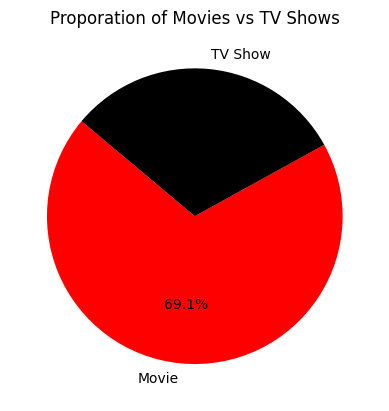

In [37]:
plt.pie(type_count, labels=type_count.index, autopct ='%1.1f%%', startangle=140,
       colors=['red', 'black'])
plt.title('Proporation of Movies vs TV Shows')
plt.ylabel('')
plt.show()

Group data by year

In [42]:
content_over_time = df.groupby(['year_added', 'type']).size().unstack().fillna(0)
print(content_over_time)

type         Movie  TV Show
year_added                 
2008           1.0      1.0
2009           2.0      0.0
2010           1.0      0.0
2011          13.0      0.0
2012           3.0      0.0
2013           6.0      5.0
2014          19.0      6.0
2015          58.0     30.0
2016         256.0    184.0
2017         861.0    361.0
2018        1255.0    429.0
2019        1497.0    656.0
2020        1312.0    697.0
2021          88.0     29.0


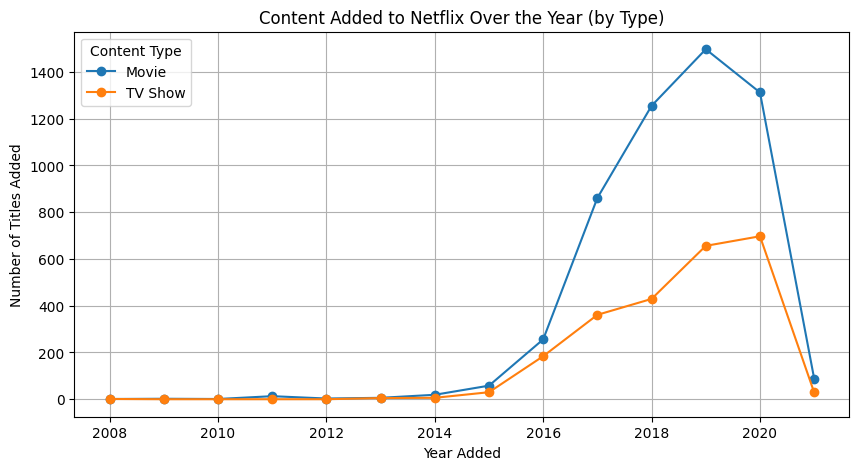

In [58]:
content_over_time.plot(kind ='line', marker='o', figsize=(10,5))
plt.title('Content Added to Netflix Over the Year (by Type)')
plt.xlabel('Year Added')
plt.ylabel('Number of Titles Added')
plt.legend(title = 'Content Type')
plt.grid()
plt.show()

In [6]:
genres = df.assign(genre=df['listed_in'].str.split(', ')).explode('genre')

In [7]:
genres

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,genre
0,s1,TV Show,3%,NaN,"João Miguel, Bianca Comparato, Michel Gomes, R...",Brazil,"August 14, 2020",2020,TV-MA,4 Seasons,"International TV Shows, TV Dramas, TV Sci-Fi &...",In a future where the elite inhabit an island ...,International TV Shows
0,s1,TV Show,3%,NaN,"João Miguel, Bianca Comparato, Michel Gomes, R...",Brazil,"August 14, 2020",2020,TV-MA,4 Seasons,"International TV Shows, TV Dramas, TV Sci-Fi &...",In a future where the elite inhabit an island ...,TV Dramas
0,s1,TV Show,3%,NaN,"João Miguel, Bianca Comparato, Michel Gomes, R...",Brazil,"August 14, 2020",2020,TV-MA,4 Seasons,"International TV Shows, TV Dramas, TV Sci-Fi &...",In a future where the elite inhabit an island ...,TV Sci-Fi & Fantasy
1,s2,Movie,7:19,Jorge Michel Grau,"Demián Bichir, Héctor Bonilla, Oscar Serrano, ...",Mexico,"December 23, 2016",2016,TV-MA,93 min,"Dramas, International Movies",After a devastating earthquake hits Mexico Cit...,Dramas
1,s2,Movie,7:19,Jorge Michel Grau,"Demián Bichir, Héctor Bonilla, Oscar Serrano, ...",Mexico,"December 23, 2016",2016,TV-MA,93 min,"Dramas, International Movies",After a devastating earthquake hits Mexico Cit...,International Movies
...,...,...,...,...,...,...,...,...,...,...,...,...,...
7784,s7785,Movie,Zulu Man in Japan,NaN,Nasty C,NaN,"September 25, 2020",2019,TV-MA,44 min,"Documentaries, International Movies, Music & M...","In this documentary, South African rapper Nast...",Music & Musicals
7785,s7786,TV Show,Zumbo's Just Desserts,NaN,"Adriano Zumbo, Rachel Khoo",Australia,"October 31, 2020",2019,TV-PG,1 Season,"International TV Shows, Reality TV",Dessert wizard Adriano Zumbo looks for the nex...,International TV Shows
7785,s7786,TV Show,Zumbo's Just Desserts,NaN,"Adriano Zumbo, Rachel Khoo",Australia,"October 31, 2020",2019,TV-PG,1 Season,"International TV Shows, Reality TV",Dessert wizard Adriano Zumbo looks for the nex...,Reality TV
7786,s7787,Movie,ZZ TOP: THAT LITTLE OL' BAND FROM TEXAS,Sam Dunn,NaN,"United Kingdom, Canada, United States","March 1, 2020",2019,TV-MA,90 min,"Documentaries, Music & Musicals",This documentary delves into the mystique behi...,Documentaries


 Most popular genres

In [11]:
# top 15 genres
top_genres_counts = genres['genre'].value_counts().reset_index()

top_genres_counts

,genre,count
0,International Movies,2437
1,Dramas,2106
2,Comedies,1471
3,International TV Shows,1199
4,Documentaries,786
5,Action & Adventure,721
6,TV Dramas,704
7,Independent Movies,673
8,Children & Family Movies,532
9,Romantic Movies,531


In [15]:
# Rename column for clarity
top_genres_counts.columns = ['genre', 'count']

top_genres_count_plot = top_genres_counts.head(15)
top_genres_count_plot

,genre,count
0,International Movies,2437
1,Dramas,2106
2,Comedies,1471
3,International TV Shows,1199
4,Documentaries,786
5,Action & Adventure,721
6,TV Dramas,704
7,Independent Movies,673
8,Children & Family Movies,532
9,Romantic Movies,531


In [21]:
import seaborn as sns 

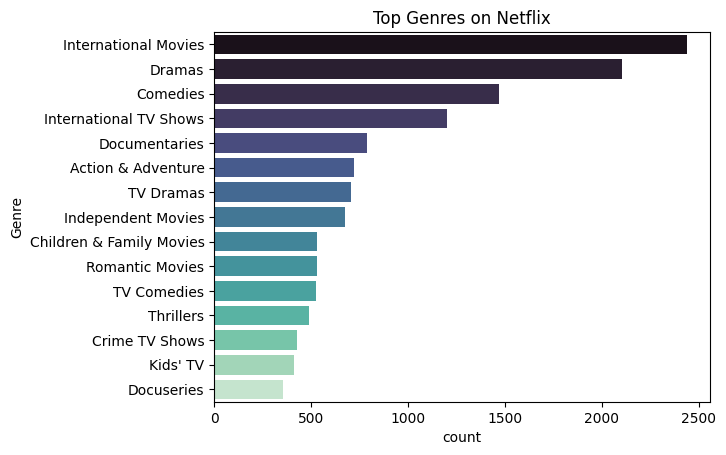

In [25]:
sns.barplot(y='genre', x='count', data=top_genres_count_plot, palette='mako', hue='genre', legend=False)
plt.title('Top Genres on Netflix')
plt.xlabel('count')
plt.ylabel('Genre')
plt.show()

Distribution of Content duration

In [39]:
# Separate movies and TV Shows
movies_df = df[df['type']=='Movie'].copy()
tv_show_df = df[df['type']=='TV Show'].copy()


# Clean and convert the duration for movies
movies_df['duration_min'] = movies_df['duration'].str.replace('min', '').astype(int)

# clean and convert the duration for tv
tv_show_df['seasons'] = tv_show_df['duration'].str.replace('Seasons', '').str.replace('Season', '').astype(int)